In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
# %env
os.chdir(os.environ.get("DATASET_PATH"))

In [12]:
concrete_data = pd.read_csv("concrete_data.csv")
concrete_data.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [13]:
df = concrete_data.copy()

- first of all what i will do is -  
    - check assumptions of lin regression   
    - then apply multiple lin reggression on data   
    - next i will scale data and then apply multiple lin reggression and compare them  

In [29]:
# check assumption 
# 1 . linear relationship of inputs with output

# fig , axes = plt.subplots(4,2,figsize = (12,10))

# amount of Cement vs Strength    

# i = 0 
# j = 0 
# for col in df.columns[:-1] :
#     sns.scatterplot(data=df , x= col, y= 'Strength', ax = axes[j][i] )
#     if i == 1 :
#         i = 0 
#         j += 1
#     else :
#         i += 1


# plt.tight_layout()
# plt.show()

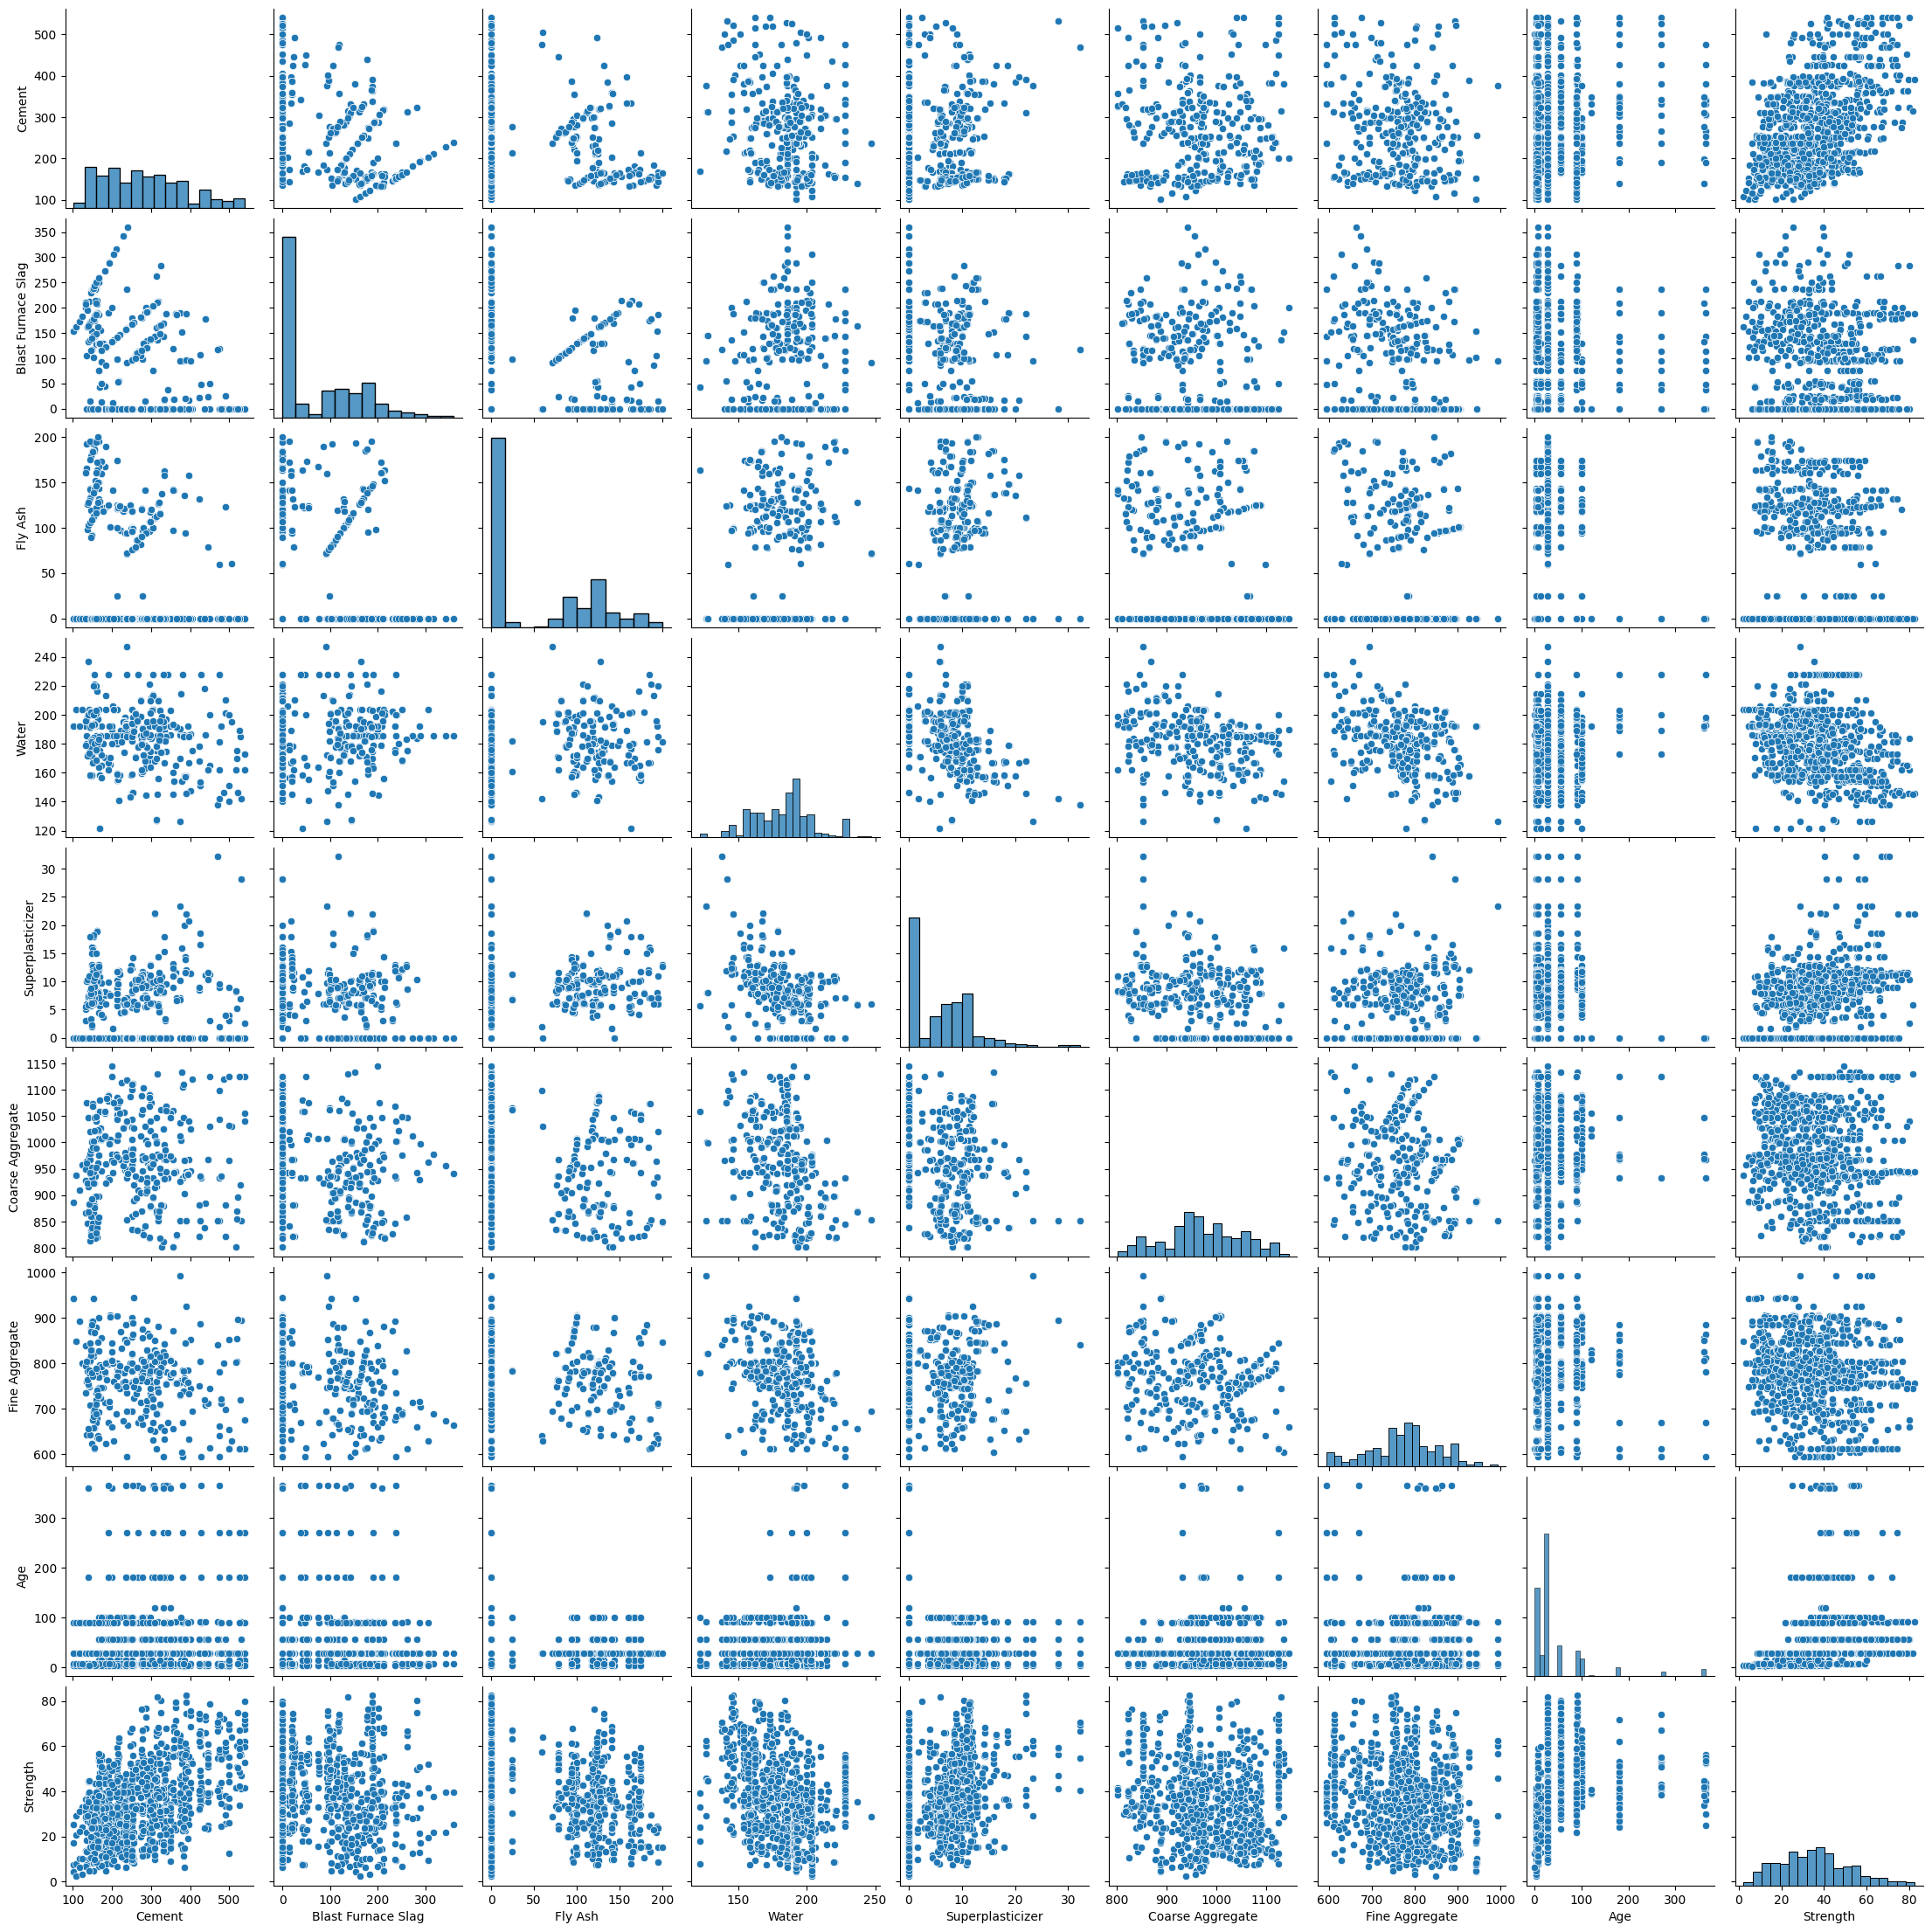

In [28]:
sns.pairplot(df)

there is no linear relationship between the input data and the output so we cant apply the multiple **linear reggression** here 

### multi lin reggression on Housing dataset

In [30]:
housing = pd.read_csv("Housing.csv")
housing.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
df = housing.drop(columns=['id','date'])

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_lot15     21

In [34]:
df.isnull().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

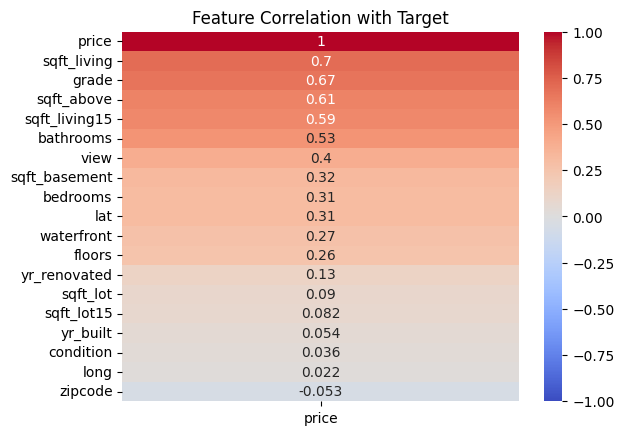

In [54]:
# relationship between input features and output

corr_matrix = df.corr()
target_corr = corr_matrix[['price']].sort_values(by='price', ascending=False)

# corr_matrix[['price']].sort_values(by='price', ascending=False)

sns.heatmap(target_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Target')
plt.show()

In [55]:
# take the only columns which are +vely collinear with price col

new_df = df[target_corr[target_corr > 0.3].dropna().index]
new_df

,price,sqft_living,grade,sqft_above,sqft_living15,bathrooms,view,sqft_basement,bedrooms,lat
0,231300.0,1180,7,1180,1340,1.00,0,0,2,47.5112
1,538000.0,2570,7,2170,1690,2.25,0,400,3,47.7210
2,180000.0,770,6,770,2720,1.00,0,0,2,47.7379
3,604000.0,1960,7,1050,1360,3.00,0,910,4,47.5208
4,510000.0,1680,8,1680,1800,2.00,0,0,3,47.6168
...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,1530,8,1530,1530,2.50,0,0,3,47.6993
21609,400000.0,2310,8,2310,1830,2.50,0,0,4,47.5107
21610,402101.0,1020,7,1020,1020,0.75,0,0,2,47.5944
21611,400000.0,1600,8,1600,1410,2.50,0,0,3,47.5345


In [57]:
from sklearn.model_selection import train_test_split

X , y = new_df.drop(columns=['price']) , new_df['price'] 

X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2, random_state=1)

In [59]:
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()
mlr.fit(X_train , y_train) 
y_pred = mlr.predict(X_test)

In [75]:
y_pred_df = pd.DataFrame(y_pred,columns=['new_price'])
y_test_df = y_test.to_frame(name='price').reset_index().drop(columns='index')
y_test_df = pd.concat([y_test_df, y_pred_df], axis=1)
y_test_df.head()

,price,new_price
0,459000.0,651142.216702
1,445000.0,498178.646664
2,1057000.0,814503.553826
3,732350.0,704002.982284
4,235000.0,234263.328060


<Axes: ylabel='Density'>

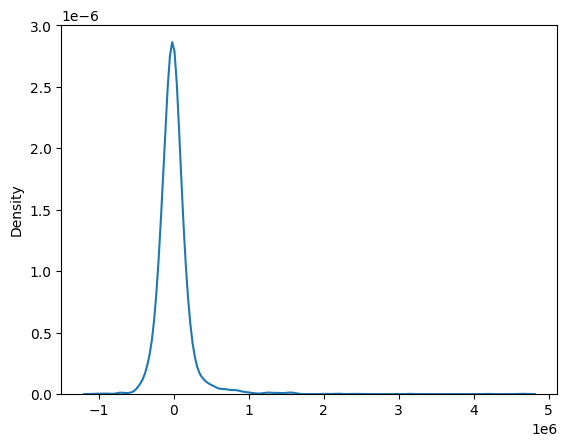

In [77]:
# check residuals
residuals = y_test_df['price'] - y_test_df['new_price']

sns.kdeplot(residuals)

### prediction with all columns 


In [79]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,231300.0,2,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [80]:
X , y= df.drop(columns=['price']) , df['price']
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2, random_state=1)


mlr = LinearRegression()
mlr.fit(X_train , y_train) 
y_pred = mlr.predict(X_test)

<Axes: xlabel='price', ylabel='Density'>

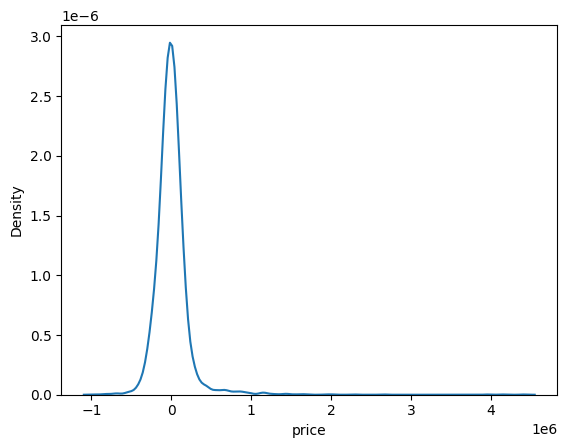

In [81]:
residuals = y_test - y_pred 
sns.kdeplot(residuals)

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error , mean_absolute_percentage_error , r2_score

print(f"mean sq. error -  {mean_squared_error(y_test,y_pred):.2f}")
print(f"root mean sq. error -  {np.sqrt(mean_squared_error(y_test,y_pred)):.2f}")
print(f"mean absolute pct error -  {mean_absolute_percentage_error(y_test,y_pred):.2%}")
print(f"r2 score -  {r2_score(y_test, y_pred):.2%}")

mean sq. error -  54219223903.22
root mean sq. error -  232850.22
mean absolute pct error -  25.30%
r2 score -  68.59%


### same distribution of residuals means this algorithm is not best for this 